In [3]:
import json
import os
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import models, transforms
from tqdm import tqdm                                                                                                                                           
from torchvision import models                                                                                                                                                        
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the saved checkpoint dict
checkpoint = torch.load("trash_severity_classifier.pt", map_location=DEVICE, weights_only=True)

# Recreate the exact same architecture used during training
model = models.efficientnet_b3(weights=None)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5, inplace=True),
    nn.Linear(1536, 4),   # 4 classes: clean, low, medium, high
)

# Restore weights from checkpoint
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
model = model.to(DEVICE)

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


TACO_ROOT = Path("./TACO")
ANNOTATIONS_FILE = TACO_ROOT / "data" / "annotations.json"
SEVERITY_LABELS = ["clean", "low", "medium", "high"]
LABEL_TO_IDX = {label: i for i, label in enumerate(SEVERITY_LABELS)}
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = len(SEVERITY_LABELS)


def predict_severity(image_path: str, model: nn.Module, tta_n: int = 8) -> dict:
    """
    Predict severity with Test-Time Augmentation (TTA).
    Runs tta_n augmented passes and averages the softmax scores.
    Set tta_n=1 to disable TTA.
    """
    tta_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    center_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    img = Image.open(image_path).convert("RGB")
    probs = torch.zeros(NUM_CLASSES)

    model.eval()
    with torch.no_grad():
        # Always include one clean center-crop pass
        t = center_transform(img).unsqueeze(0).to(DEVICE)
        probs += torch.softmax(model(t), dim=1).squeeze().cpu()
        # Remaining TTA passes
        for _ in range(tta_n - 1):
            t = tta_transform(img).unsqueeze(0).to(DEVICE)
            probs += torch.softmax(model(t), dim=1).squeeze().cpu()

    probs /= tta_n
    pred_idx = int(probs.argmax())
    return {
        "severity": SEVERITY_LABELS[pred_idx],
        "confidence": round(probs[pred_idx].item(), 4),
        "scores": {label: round(p.item(), 4) for label, p in zip(SEVERITY_LABELS, probs)},
    }

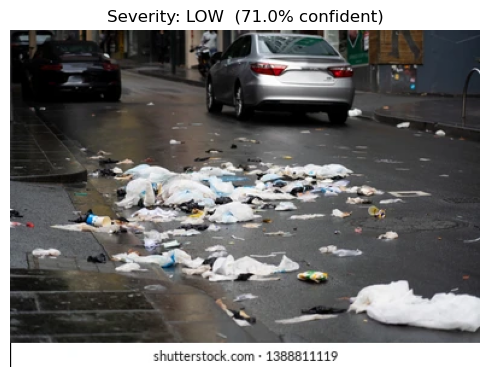

Scores:
  clean    0.0417  █
  low      0.7099  ████████████████████████████
  medium   0.1315  █████
  high     0.1169  ████


In [5]:
IMAGE_PATH = TACO_ROOT / "data" / "new_data" / "garbage-on-street-after-windy-260nw-1388811119.webp"

result = predict_severity(IMAGE_PATH, model, tta_n=8)

img_display = Image.open(IMAGE_PATH)
plt.figure(figsize=(5, 5))
plt.imshow(img_display)
plt.axis("off")
plt.title(f"Severity: {result['severity'].upper()}  ({result['confidence']*100:.1f}% confident)")
plt.tight_layout()
plt.show()

print("Scores:")
for label, score in result["scores"].items():
    bar = "█" * int(score * 40)
    print(f"  {label:8s} {score:.4f}  {bar}")

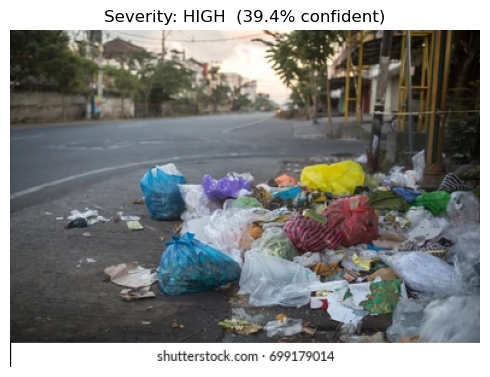

Scores:
  clean    0.0408  █
  low      0.2696  ██████████
  medium   0.2957  ███████████
  high     0.3939  ███████████████


In [6]:
IMAGE_PATH = TACO_ROOT / "data" / "new_data" / "major-garbage-sidewalk.webp"

result = predict_severity(IMAGE_PATH, model, tta_n=8)

img_display = Image.open(IMAGE_PATH)
plt.figure(figsize=(5, 5))
plt.imshow(img_display)
plt.axis("off")
plt.title(f"Severity: {result['severity'].upper()}  ({result['confidence']*100:.1f}% confident)")
plt.tight_layout()
plt.show()

print("Scores:")
for label, score in result["scores"].items():
    bar = "█" * int(score * 40)
    print(f"  {label:8s} {score:.4f}  {bar}")